In [1]:
# 修改工作路径
import numpy as np
import pandas as pd

import os
os.chdir('/root/PQ20241025/') # 修改工作路径

In [2]:
data=pd.read_csv('./Major_revision/FieldData/other_yield.csv')
data

,OP,PRE,TMP,PET,SOC,pH,BULK,CEC,CLAY,SILT,...,Nfer,Kfer,Crop,YIELD,X,Y,Region,YEAR,cooks_d,Region_old
0,5.7,347.3,2.6,897.8,2.19,8.1,1.75,17.06,22.6,41.78,...,1,1,Oil,2517.0,120.81790,45.68542,内蒙古自治区,2012,5.205764e-07,内蒙古自治区
1,9.2,923.5,14.2,866.7,1.70,5.3,1.69,11.00,19.0,41.00,...,1,1,Oil,2626.5,105.95350,27.06333,贵州省,2008,2.822700e-06,贵州省
2,11.3,1397.5,17.8,1101.4,0.15,6.3,1.73,13.00,21.0,40.00,...,1,1,Cash,3615.0,75.80000,30.90000,Asia,2008,6.581532e-06,湖北省
3,23.9,934.0,15.2,788.5,1.58,8.6,1.77,16.00,24.0,32.00,...,1,1,Oil,1881.0,105.95170,32.33694,四川省,2009,6.445539e-07,四川省
4,36.5,1588.8,16.8,991.9,1.48,5.2,1.85,18.00,31.0,34.00,...,0,0,Veg,18001.5,120.66370,29.22580,浙江省,2012,3.296562e-05,浙江省
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57611,21.3,706.0,2.7,636.5,3.47,5.7,1.75,19.66,23.6,50.47,...,1,1,Pulses,2715.0,133.93806,47.41028,黑龙江省,2011,2.360941e-06,黑龙江省
57612,22.6,204.1,7.7,880.5,0.99,8.4,1.58,7.00,13.0,24.00,...,1,1,Oil,3175.5,104.05447,37.24650,甘肃省,2011,2.362389e-06,甘肃省
57613,15.7,1171.9,17.2,866.3,0.79,5.7,1.69,11.00,19.0,41.00,...,0,0,Oil,1125.0,103.90350,29.26375,四川省,2008,3.039235e-05,四川省
57614,6.7,674.5,12.1,972.6,0.52,7.9,1.70,19.56,20.0,43.16,...,0,0,Veg,30525.0,109.32090,35.24290,陕西省,2009,4.912634e-07,陕西省


# PINNs模型构建

In [3]:
# 基础包
import pandas as pd
import numpy as np
# 绘图的包
import matplotlib.pyplot as plt

import matplotlib as mpl
# PINNs的包
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
# GIS的包
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import rasterio

import scipy.stats as stats

In [4]:
# 1. 检查CUDA可用性
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
# 对训练集和测试集进行归一化
def custom_normalize(data, data_min, data_max):
    return (data - data_min) / (data_max - data_min + 1e-8)  # 加上一个小的数值防止除以零

def custom_denormalize(data_normalized, data_min, data_max):
    return data_normalized * (data_max - data_min + 1e-8) + data_min

In [6]:
data["Crop"].value_counts()

Crop
Oil        14163
Roots      12163
Pulses     11378
Veg         9170
Cash        7479
Cereals     3263
Name: count, dtype: int64

In [7]:
# One-hot 编码 Crop 变量
data_one_hot = pd.get_dummies(data, columns=['Crop'],dtype=int)
# 确保 Ploss 放在最后
columns = [col for col in data_one_hot.columns if col != 'YIELD'] + ['YIELD']
data = data_one_hot[columns]
data

,OP,PRE,TMP,PET,SOC,pH,BULK,CEC,CLAY,SILT,...,YEAR,cooks_d,Region_old,Crop_Cash,Crop_Cereals,Crop_Oil,Crop_Pulses,Crop_Roots,Crop_Veg,YIELD
0,5.7,347.3,2.6,897.8,2.19,8.1,1.75,17.06,22.6,41.78,...,2012,5.205764e-07,内蒙古自治区,0,0,1,0,0,0,2517.0
1,9.2,923.5,14.2,866.7,1.70,5.3,1.69,11.00,19.0,41.00,...,2008,2.822700e-06,贵州省,0,0,1,0,0,0,2626.5
2,11.3,1397.5,17.8,1101.4,0.15,6.3,1.73,13.00,21.0,40.00,...,2008,6.581532e-06,湖北省,1,0,0,0,0,0,3615.0
3,23.9,934.0,15.2,788.5,1.58,8.6,1.77,16.00,24.0,32.00,...,2009,6.445539e-07,四川省,0,0,1,0,0,0,1881.0
4,36.5,1588.8,16.8,991.9,1.48,5.2,1.85,18.00,31.0,34.00,...,2012,3.296562e-05,浙江省,0,0,0,0,0,1,18001.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57611,21.3,706.0,2.7,636.5,3.47,5.7,1.75,19.66,23.6,50.47,...,2011,2.360941e-06,黑龙江省,0,0,0,1,0,0,2715.0
57612,22.6,204.1,7.7,880.5,0.99,8.4,1.58,7.00,13.0,24.00,...,2011,2.362389e-06,甘肃省,0,0,1,0,0,0,3175.5
57613,15.7,1171.9,17.2,866.3,0.79,5.7,1.69,11.00,19.0,41.00,...,2008,3.039235e-05,四川省,0,0,1,0,0,0,1125.0
57614,6.7,674.5,12.1,972.6,0.52,7.9,1.70,19.56,20.0,43.16,...,2009,4.912634e-07,陕西省,0,0,0,0,0,1,30525.0


In [8]:
# 定义需要归一化的特征
features_to_normalize = ['OP', 'PRE', 'TMP', 'PET', 'SOC', 'pH', 'BULK', 'CEC',
                         'CLAY', 'SILT', 'SAND', 'SLOPE', 'Pfer']# 提取特征和目标变量

all_features = ['OP', 'PRE', 'TMP', 'PET', 'SOC', 'pH', 'BULK', 'CEC',
                'CLAY', 'SILT', 'SAND', 'SLOPE', 'IRR', 'Pfer', 'Nfer', 'Kfer',
                'Crop_Cash','Crop_Cereals','Crop_Oil','Crop_Pulses','Crop_Roots','Crop_Veg']
X = data[all_features].values  # 特征数据
Y = data['YIELD'].values.reshape(-1, 1)  # 目标数据

# 将数据转换为 PyTorch 张量
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

In [9]:
# 划分数据集，测试集占20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=17)

In [ ]:
# 作物 one-hot 列
crop_cols = ['Crop_Cash','Crop_Cereals','Crop_Oil','Crop_Pulses','Crop_Roots','Crop_Veg']
crop_indices = [all_features.index(c) for c in crop_cols]

# 从 one-hot 转成作物组整数编号
# argmax后的顺序就是 crop_cols 的顺序：
# 0 Crop_Cash
# 1 Crop_Cereals
# 2 Crop_Oil
# 3 Crop_Pulses
# 4 Crop_Roots
# 5 Crop_Veg
crop_group_idx_train = X_train[:, crop_indices].argmax(dim=1).long()
crop_group_idx_test = X_test[:, crop_indices].argmax(dim=1).long()

In [10]:
# 获取需要归一化的列索引
normalize_indices = [all_features.index(f) for f in features_to_normalize]

# 计算训练集中需要归一化列的最小值和最大值
X_train_to_normalize = X_train[:, normalize_indices]
X_min = X_train_to_normalize.min(dim=0, keepdim=True)[0]
X_max = X_train_to_normalize.max(dim=0, keepdim=True)[0]

# 创建一个拷贝以存放归一化后的训练集和测试集
X_train_normalized = X_train.clone()
X_test_normalized = X_test.clone()

In [11]:
# 对需要归一化的列进行归一化
X_train_normalized[:, normalize_indices] = custom_normalize(X_train_to_normalize, X_min, X_max)
X_test_normalized[:, normalize_indices] = custom_normalize(X_test[:, normalize_indices], X_min, X_max)

X_param_normalized = X_train_normalized[:,1:22] #参数网络，排除OP
print('训练数据：',X_train_normalized.shape)
print('参数数据：',X_param_normalized.shape)

训练数据： torch.Size([46092, 22])
参数数据： torch.Size([46092, 21])


In [12]:
# 作物 one-hot 列
crop_cols = ['Crop_Cash','Crop_Cereals','Crop_Oil','Crop_Pulses','Crop_Roots','Crop_Veg']
crop_indices = [all_features.index(c) for c in crop_cols]

# 保存每个作物的 Y 最小值和最大值（只用训练集算）
y_min_dict = {}
y_max_dict = {}

for crop_name, crop_idx in zip(crop_cols, crop_indices):
    train_mask = X_train[:, crop_idx] == 1
    
    if train_mask.sum() > 0:
        y_train_crop = Y_train[train_mask]
        y_min_dict[crop_name] = y_train_crop.min().item()
        y_max_dict[crop_name] = y_train_crop.max().item()

print("Y min by crop:", y_min_dict)
print("Y max by crop:", y_max_dict)

Y min by crop: {'Crop_Cash': 2005.5, 'Crop_Cereals': 2000.5, 'Crop_Oil': 1000.5, 'Crop_Pulses': 1005.0, 'Crop_Roots': 10000.5, 'Crop_Veg': 12000.0}
Y max by crop: {'Crop_Cash': 6420.0, 'Crop_Cereals': 8655.0, 'Crop_Oil': 5613.0, 'Crop_Pulses': 3627.0, 'Crop_Roots': 55500.0, 'Crop_Veg': 118545.0}


In [13]:
Y_train_normalized = Y_train.clone()
Y_test_normalized = Y_test.clone()

for crop_name, crop_idx in zip(crop_cols, crop_indices):
    train_mask = X_train[:, crop_idx] == 1
    test_mask = X_test[:, crop_idx] == 1

    y_min = y_min_dict[crop_name]
    y_max = y_max_dict[crop_name]

    if train_mask.sum() > 0:
        Y_train_normalized[train_mask] = custom_normalize(
            Y_train[train_mask], y_min, y_max
        )

    if test_mask.sum() > 0:
        Y_test_normalized[test_mask] = custom_normalize(
            Y_test[test_mask], y_min, y_max
        )

In [14]:
y_scale_df = pd.DataFrame({
    "Crop": crop_cols,
    "Y_min": [y_min_dict[c] for c in crop_cols],
    "Y_max": [y_max_dict[c] for c in crop_cols]
})

print(y_scale_df)

           Crop    Y_min     Y_max
0     Crop_Cash   2005.5    6420.0
1  Crop_Cereals   2000.5    8655.0
2      Crop_Oil   1000.5    5613.0
3   Crop_Pulses   1005.0    3627.0
4    Crop_Roots  10000.5   55500.0
5      Crop_Veg  12000.0  118545.0


In [ ]:
# 转换为需要梯度的张量并移动到设备上
X_param = X_param_normalized.to(device)

data_x_train = X_train_normalized.requires_grad_(True).to(device)
data_y_train = Y_train_normalized.to(device)

data_x_test = X_test_normalized.to(device)
data_y_test = Y_test_normalized.to(device)

# 检查 requires_grad 属性
print("data_x_train requires_grad:", data_x_train.requires_grad)  # 应为 True
print("data_y_train requires_grad:", data_y_train.requires_grad)  # 应为 False
print("data_x_test requires_grad:", data_x_test.requires_grad)    # 应为 False

# 检查张量设备
print("data_x_train device:", data_x_train.device)  # 应与 device 一致
print("data_y_train device:", data_y_train.device)  # 应与 device 一致
print("data_x_test device:", data_x_test.device)    # 应与 device 一致

data_x_train requires_grad: True
data_y_train requires_grad: False
data_x_test requires_grad: False
data_x_train device: cuda:0
data_y_train device: cuda:0
data_x_test device: cuda:0


In [ ]:
# ===== 构造 OP collocation points（步长=5）=====
op_grid = torch.arange(0, 101, 5, device=device).float()   # 0,5,...,100  共21个点
op_grid_norm = custom_normalize(op_grid, X_min[:, 0].to(device), X_max[:, 0].to(device))

n_train = data_x_train.shape[0]
n_op = op_grid_norm.shape[0]

# 把每个训练样本复制 n_op 份，并把第0列(OP)替换为 op_grid_norm
x_colloc = data_x_train.detach().clone()   
x_colloc = x_colloc.repeat_interleave(n_op, dim=0)         # [n_train*n_op, 22]
x_colloc[:, 0] = op_grid_norm.repeat(n_train)              # 每个样本对应一条OP曲线

x_colloc = x_colloc.requires_grad_(True)                   # 关键：要对OP求导
x_param_colloc = x_colloc[:, 1:22]                         # param net输入(不含OP)

# 新增：collocation点对应的作物组编号
crop_group_idx_colloc = crop_group_idx_train.repeat_interleave(n_op)

In [17]:
import random
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 尽量使用确定性算法（⚠️ 有些算子会报错）
    torch.use_deterministic_algorithms(False)

set_seed(7)

In [ ]:
# 主网络：用于预测
class YieldPredictionModel(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(YieldPredictionModel, self).__init__()
        layers = []
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.Tanh())
            input_size = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x)

# 子网络：动态生成 a, b, c 参数
class ParameterNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size=3):
        super(ParameterNetwork, self).__init__()
        layers = []
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.Tanh())
            input_size = hidden_size
        layers.append(nn.Linear(hidden_size, output_size))
        self.network = nn.Sequential(*layers)
        

    def forward(self, x):
        return self.network(x)

In [ ]:
class MultiParameterNetwork(nn.Module):
    def __init__(self, input_size=21, hidden_sizes=[50], output_size=3):
        super(MultiParameterNetwork, self).__init__()

        self.group_names = [
            "cereal_crops",      # 0
            "legume_crops",      # 1
            "oil_crops",         # 2
            "rhizome_crops",     # 3
            "vegetables_fruits", # 4
            "other_cash_crops"   # 5
        ]

        self.networks = nn.ModuleDict({
            group_name: ParameterNetwork(
                input_size=input_size,
                hidden_sizes=hidden_sizes,
                output_size=output_size
            )
            for group_name in self.group_names
        })

    def forward(self, x, crop_group_idx):
        """
        x: [N, input_size]
        crop_group_idx: [N]，取值 0~5
        返回:
            out: [N, output_size]
        """
        out = torch.zeros(x.size(0), 3, device=x.device, dtype=x.dtype)

        for i, group_name in enumerate(self.group_names):
            mask = (crop_group_idx == i)
            if mask.any():
                out[mask] = self.networks[group_name](x[mask])

        return out


In [ ]:
# YieldPredictionModel 输入特征包括 OP 和其他特征，共22个特征
yield_model = YieldPredictionModel(input_size=22, hidden_sizes=[32, 64, 32], output_size=1).to(device)

# ParameterNetwork 输入特征不包括 OP，共21个特征
# 现在改为：一个共享主网络 + 六个 crop-group-specific subnetworks
param_model = MultiParameterNetwork(input_size=21, hidden_sizes=[50], output_size=3).to(device)

# 定义优化器，将主网络和参数网络的参数一起优化
optimizer = torch.optim.Adam(
    [
        {"params": yield_model.parameters(), "lr": 0.01},
        {"params": param_model.parameters(), "lr": 0.0001},
    ]
)

In [ ]:
def pinn_loss_with_boundary(
    y_pred_obs, y_true_obs,
    data_x_obs,                     # 原训练观测点（用于数据loss）
    x_colloc, x_param_colloc,       # OP梯度配点（用于物理loss）
    crop_group_idx_obs,             # 新增：观测点所属作物组
    crop_group_idx_colloc,          # 新增：collocation点所属作物组
    epoch, epochs
):
    # ========= 数据误差（观测点）=========
    mse_loss_data = nn.MSELoss()(y_pred_obs, y_true_obs)

    # ========= 物理误差（collocation点：沿OP=0..100）=========
    y_pred_col = yield_model(x_colloc)

    # 按照样本所属作物组，调用对应的参数子网络
    abc_col = param_model(x_param_colloc, crop_group_idx_colloc)

    a = abc_col[:, 0]
    b = abc_col[:, 1]
    c = abc_col[:, 2]

    dy_dop = torch.autograd.grad(
        y_pred_col, x_colloc,
        grad_outputs=torch.ones_like(y_pred_col),
        create_graph=True
    )[0][:, 0]  # 对第0列OP求导

    k = 10
    # 你的目标微分形式（保持原写法）
    phys_target = 10 * b * (c * torch.exp(-c * k * x_colloc[:, 0]))
    diff_loss = torch.mean((dy_dop - phys_target) ** 2)

    # ========= 正则（collocation点上约束）=========
    l2_reg_c = torch.norm(torch.relu(c - 2), 2) + torch.norm(torch.relu(1 - c), 2)
    l2_reg_b = torch.norm(torch.relu(b - 2), 2) + torch.norm(torch.relu(0 - b), 2)
    l2_reg_a = torch.norm(torch.relu(a - 1), 2) + torch.norm(torch.relu(0 - a), 2)
    reg_loss = l2_reg_a + l2_reg_b + l2_reg_c

    # ========= 权重（保持你的原设定）=========
    lambda_data = 100
    lambda_diff = 10 * min(epoch / (0.5 * epochs), 500.0)
    lambda_reg = 0.3

    total = lambda_data * mse_loss_data + lambda_diff * diff_loss + lambda_reg * reg_loss

    return total, lambda_data*mse_loss_data, lambda_diff*diff_loss, lambda_reg*reg_loss, a.mean(), b.mean(), c.mean()

In [21]:
# 切换到训练模式
yield_model.train()
param_model.train()
print("Model is now in training mode.")

Model is now in training mode.


In [ ]:
loss_history = []
epochs = 16500

for epoch in range(epochs):
    optimizer.zero_grad()

    # 观测点预测（数据loss）
    y_pred_train_obs = yield_model(data_x_train)

    loss, data_loss, diff_loss, reg_loss, a, b, c = pinn_loss_with_boundary(
        y_pred_train_obs, data_y_train,
        data_x_train,
        x_colloc, x_param_colloc,
        crop_group_idx_train,        # 新增
        crop_group_idx_colloc,       # 新增
        epoch, epochs
    )

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Total={loss.item():.4f} Data={data_loss.item():.4f} Diff={diff_loss.item():.4f} Reg={reg_loss.item():.4f}")

Epoch [500/16500] Total=2.1870 Data=2.0730 Diff=0.0422 Reg=0.0717
Epoch [1000/16500] Total=2.0305 Data=2.0116 Diff=0.0188 Reg=0.0000
Epoch [1500/16500] Total=1.9421 Data=1.9292 Diff=0.0129 Reg=0.0000
Epoch [2000/16500] Total=1.8853 Data=1.8754 Diff=0.0099 Reg=0.0000
Epoch [2500/16500] Total=1.8031 Data=1.7932 Diff=0.0099 Reg=0.0000
Epoch [3000/16500] Total=1.7477 Data=1.7392 Diff=0.0085 Reg=0.0000
Epoch [3500/16500] Total=1.6818 Data=1.6730 Diff=0.0088 Reg=0.0000
Epoch [4000/16500] Total=1.6435 Data=1.6340 Diff=0.0095 Reg=0.0000
Epoch [4500/16500] Total=1.5714 Data=1.5609 Diff=0.0105 Reg=0.0000
Epoch [5000/16500] Total=1.5084 Data=1.5012 Diff=0.0072 Reg=0.0000
Epoch [5500/16500] Total=1.4418 Data=1.4353 Diff=0.0065 Reg=0.0000
Epoch [6000/16500] Total=1.3820 Data=1.3758 Diff=0.0062 Reg=0.0000
Epoch [6500/16500] Total=1.3418 Data=1.3356 Diff=0.0062 Reg=0.0000
Epoch [7000/16500] Total=1.3071 Data=1.3018 Diff=0.0053 Reg=0.0000
Epoch [7500/16500] Total=1.2645 Data=1.2597 Diff=0.0048 Reg=0.0

效果评估

In [26]:
# 开始模型评估模式
yield_model.eval()
param_model.eval()
print("Model is now in evaluation mode.")

Model is now in evaluation mode.


In [30]:
# 在测试集洱和训练集上进行预测
with torch.no_grad():
    y_pred_test = yield_model(data_x_test)

with torch.no_grad():
    y_pred_train = yield_model(data_x_train)

In [31]:
# 将预测值和真实值反归一化
y_pred_test_denormalized = y_pred_test
y_test_denormalized = data_y_test

y_pred_train_denormalized = y_pred_train
y_train_denormalized = data_y_train

# 将数据从 PyTorch 张量转换为 NumPy 数组
y_pred_test_np = y_pred_test_denormalized.cpu().numpy()
y_test_np = y_test_denormalized.cpu().numpy()

# 将数据从 PyTorch 张量转换为 NumPy 数组
y_pred_train_np = y_pred_train_denormalized.cpu().numpy()
y_train_np = y_train_denormalized.cpu().numpy()

# 计算 R2
r2_test = r2_score(y_test_np, y_pred_test_np)
r2_train = r2_score(y_train_np, y_pred_train_np)
print(f'R2 on test set: {r2_test:.4f}')
print(f'R2 on train set: {r2_train:.4f}')

R2 on test set: 0.6584
R2 on train set: 0.7620


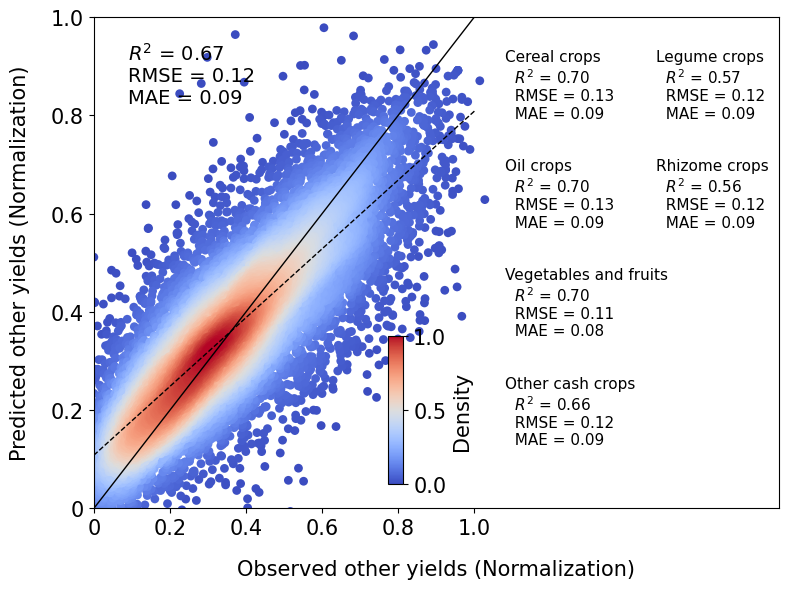

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

x_obs = np.asarray(y_test_np).ravel()
y_pre = np.asarray(y_pred_test_np).ravel()

mask = np.isfinite(x_obs) & np.isfinite(y_pre)
x_obs = x_obs[mask]
y_pre = y_pre[mask]

# ===== KDE 密度 =====
xy = np.vstack([x_obs, y_pre])
z = gaussian_kde(xy)(xy)

# ===== 归一化到 0–1 =====
z = (z - z.min()) / (z.max() - z.min())

# 高密度点后画
idx = z.argsort()
x_obs, y_pre, z = x_obs[idx], y_pre[idx], z[idx]

plt.figure(figsize=(8, 6))

sc = plt.scatter(x_obs, y_pre, c=z, s=40, cmap='coolwarm', vmin=0, vmax=1, edgecolors='none')

# ===== colorbar =====
ax = plt.gca()
cax = ax.inset_axes([0.43, 0.05, 0.022, 0.3])  # [左, 下, 宽, 高]
cbar = plt.colorbar(sc, cax=cax,fraction=0.1, pad=0.05, aspect=20)
cbar.set_label('Density', fontsize=15)
cbar.set_ticks([0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=15)

# ===== 1:1 线 =====
plt.plot([0, 1], [0, 1], color='black', linewidth=1)

# ===== 拟合线 =====
coef = np.polyfit(x_obs, y_pre, 1)
fit_line = np.poly1d(coef)
x_fit = np.linspace(0, 1, 200)
plt.plot(x_fit, fit_line(x_fit), linestyle='--', color='black', linewidth=1)

# ===== 指标文本（左上角）=====
R2 = 0.67#r2_score(x_obs, y_pre)
RMSE = np.sqrt(mean_squared_error(x_obs, y_pre))
MAE = mean_absolute_error(x_obs, y_pre)

plt.text(0.05, 0.95, f'$R^2$ = {R2:.2f}\nRMSE = {RMSE:.2f}\nMAE = {MAE:.2f}',
    transform=plt.gca().transAxes, fontsize=14, verticalalignment='top')

plt.text(
    0.6, 0.97,
    f'''
Cereal crops
  $R^2$ = 0.70
  RMSE = 0.13
  MAE = 0.09

  
Oil crops
  $R^2$ = 0.70
  RMSE = 0.13
  MAE = 0.09

  
Vegetables and fruits
  $R^2$ = 0.70
  RMSE = 0.11
  MAE = 0.08

  
Other cash crops
  $R^2$ = 0.66
  RMSE = 0.12
  MAE = 0.09''',
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top'
)
plt.text(
    0.82, 0.97,
    f'''
Legume crops
  $R^2$ = 0.57
  RMSE = 0.12
  MAE = 0.09

  
Rhizome crops
  $R^2$ = 0.56
  RMSE = 0.12
  MAE = 0.09''',
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top'
)

# ===== 坐标轴 =====
plt.xlim(0, 1.8)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.01, 0.2), ['0', '0.2', '0.4', '0.6', '0.8', '1.0'],fontsize=15)
plt.yticks(np.arange(0, 1.01, 0.2), ['0', '0.2', '0.4', '0.6', '0.8', '1.0'],fontsize=15)
plt.xlabel('Observed other yields (Normalization)', fontsize=15, labelpad=15)
plt.ylabel('Predicted other yields (Normalization)', fontsize=15, labelpad=15)

plt.tight_layout()
plt.show()